In [60]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from gsw import SA_from_SP, CT_from_t, rho, p_from_z
import cartopy.crs as ccrs

import geopandas as gpd

import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.tri as mtri

import cartopy.feature as cfeature

from scipy.interpolate import griddata


import matplotlib.tri as mtri

from scipy.interpolate import griddata 
from scipy.ndimage import gaussian_filter 


%matplotlib inline

In [61]:
## Load in NJDEP Data
df = pd.read_csv('TowsCatchTable.csv')

In [62]:
df.drop_duplicates("ID")

,ID,CRUCODE,STA,STRATUM,TOW,YRMODA,TIME,MINOUT,STARTDEPTH,ENDDEPTH,...,ELONG,TEMPSURF,TEMPBOT,SALSURF,SALBOT,DOSURF,DOBOT,SPP,WEIGHT,NUMBER
0,19882006,19882,6,12,25,19880821,705,22.2,9.0000,9.0000,...,7360.000,19.000000,11.200000,31.000000,31.500000,7.400000,3.300000,131,73.88,7786.0
15,19882007,19882,7,13,16,19880821,1000,32.8,17.0000,18.0000,...,7358.000,20.500000,10.000000,32.000000,34.000000,7.700000,4.400000,121,0.08,1.0
19,19882002,19882,2,12,9,19880820,1200,30.7,7.0000,7.0000,...,7358.000,20.800000,17.000000,30.000000,32.000000,7.500000,5.700000,196,0.30,1.0
40,19882003,19882,3,13,5,19880820,1420,24.8,13.0000,12.0000,...,7357.000,20.000000,11.500000,28.500000,30.000000,7.600000,5.000000,131,9.61,2363.0
56,19882004,19882,4,14,17,19880820,1720,32.1,19.0000,19.0000,...,7352.000,19.900000,7.200000,33.000000,34.000000,7.500000,5.500000,171,0.20,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134485,20244144,20244,144,13,10,20240827,906,20.0,17.6784,17.6784,...,7355.328,21.983418,12.314314,30.791020,32.073475,8.151429,5.729492,13,1.05,2.0
134509,20244145,20244,145,13,8,20240827,1031,20.0,16.1544,17.9832,...,7355.286,22.336259,13.451885,30.634815,31.961538,8.198519,5.840940,13,0.40,1.0
134530,20244146,20244,146,14,1,20240827,1148,20.0,17.9832,22.2504,...,7352.404,22.202850,12.332697,27.300256,31.987871,8.419500,5.080774,24,2.45,2.0
134551,20244147,20244,147,12,10,20240827,1313,20.0,5.7912,6.4008,...,7357.715,22.759333,22.246471,27.175397,28.369038,8.858730,8.457788,13,135.58,28.0


In [63]:
## Creating year and cruise columns
df['year'] = df['CRUCODE'].astype(str).str[:4].astype(int)
df['cruise'] = df['CRUCODE'].astype(str).str[4:5].astype(int)

In [64]:
# Dropping years 1988,1989,2020-2024 to match NEAMAP  
df2 = df.set_index('year')
df2 = df2.drop([1988,1989,2020,2022,2023,2024])

In [65]:
## Reseting the index to be the trawl ID number 
df=df2.reset_index().set_index("ID").sort_index()

In [66]:
df['YRMODA'] = pd.to_datetime(df['YRMODA'], format='%Y%m%d')

In [67]:
df["DOY"] = df["DOY"] = pd.to_datetime(df['YRMODA'], format='%Y%m%d').dt.dayofyear

In [68]:
df['month'] = df["YRMODA"].astype(str).str[5:7].astype(int)

##### Converting lat/lon from DDM to Decimal Degrees

In [69]:
## the dep data is in DDM and we don't want that 

df['lat']=(df['SLAT'].astype(str).str[:2].astype(float))
df['latmin']=((df['SLAT'].astype(str).str[2:8].astype(float))/60)
df["SLAT"]=df.lat+df.latmin

In [70]:
df['SLONG']=df['SLONG'].fillna("00").astype(float)

In [71]:
df['lon']=df['SLONG'].astype(str).str[:2].astype(float)
df['lonmin']=((df['SLONG'].astype(str).str[2:8].astype(float))/60)
df['SLONG']=-(df.lon+df.lonmin)

In [72]:
df['ELAT']=df['ELAT'].fillna("00").astype(float)

In [73]:
df['lat']=(df['ELAT'].astype(str).str[:2].astype(float))
df['latmin']=((df['ELAT'].astype(str).str[2:8].astype(float))/60)
df["ELAT"]=df.lat+df.latmin

In [74]:
df['ELONG']=df['ELONG'].fillna("00").astype(float)

In [75]:
df['lon']=df['ELONG'].astype(str).str[:2].astype(float)
df['lonmin']=((df['ELONG'].astype(str).str[2:8].astype(float))/60)
df['ELONG']=-(df.lon+df.lonmin)

In [76]:
df = df.reset_index()
df = df.drop(columns={'STA','TOW','CRUCODE','lat', 'latmin', 'lon', 'lonmin'}) ## getting rid of unnecessary columns

##### Extracting Just the Ocean Data

In [77]:
df.columns

df_ocean = df[['ID', 'year', 'STRATUM', 'YRMODA', 'TIME', 'MINOUT',
       'STARTDEPTH', 'ENDDEPTH', 'MINDEPTH', 'MAXDEPTH', 'SLAT', 'SLONG',
       'ELAT', 'ELONG', 'TEMPSURF', 'TEMPBOT', 'SALSURF', 'SALBOT', 'DOSURF',
       'DOBOT', 'cruise', 'DOY', 'month']]

df_ocean = df_ocean.drop_duplicates("ID")

df_ocean = df_ocean.reset_index()

In [78]:
df_ocean

,index,ID,year,STRATUM,YRMODA,TIME,MINOUT,STARTDEPTH,ENDDEPTH,MINDEPTH,...,ELONG,TEMPSURF,TEMPBOT,SALSURF,SALBOT,DOSURF,DOBOT,cruise,DOY,month
0,0,19901001,1990,20,1990-02-06,855,20.5,16.00,18.000,16.000,...,-74.225167,4.500000,4.800000,33.000000,33.000000,9.500000,9.600000,1,37,2
1,8,19901002,1990,19,1990-02-06,1042,19.5,18.00,16.000,15.000,...,-74.271167,3.600000,3.800000,33.000000,33.000000,9.700000,10.100000,1,37,2
2,16,19901003,1990,19,1990-02-06,1213,20.0,10.00,9.000,9.000,...,-74.288000,4.600000,4.600000,32.000000,32.000000,9.900000,9.400000,1,37,2
3,31,19901004,1990,23,1990-02-07,905,20.0,20.00,24.000,20.000,...,-74.420333,4.400000,4.400000,35.000000,34.000000,10.000000,9.700000,1,38,2
4,42,19901005,1990,22,1990-02-07,1040,20.7,20.00,18.000,18.000,...,-74.519833,4.600000,4.500000,31.000000,30.500000,10.100000,10.200000,1,38,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5543,117242,20195144,2019,17,2019-11-10,1516,20.0,26.84,25.010,24.705,...,-73.885867,14.515163,14.566818,32.167674,32.195303,8.532558,8.368333,5,314,11
5544,117258,20195145,2019,17,2019-11-10,1627,20.0,22.57,23.180,NaN,...,-73.888583,14.430667,14.571575,32.200000,32.308250,8.499804,8.381500,5,314,11
5545,117275,20195146,2019,17,2019-11-11,657,20.0,21.96,24.400,NaN,...,-73.890217,13.588981,15.183845,31.700769,32.926186,8.599231,7.582784,5,315,11
5546,117288,20195147,2019,16,2019-11-11,858,20.0,17.69,15.860,NaN,...,-74.010800,13.961362,15.010435,31.471064,32.692118,8.167021,7.293176,5,315,11


In [79]:
def density(temperature, depth, salinity, latitude, longitude):
    """
    Calculates density given practical salinity, depth, latitude,
    and longitude using Gibbs gsw SA_from_SP and rho functions.
    Args:
        temperature (_type_): temperature (C)
        depth (_type_): depth, positive up (m)
        salinity (array): salinity
        latitude (array): latitude (decimal degrees)
        longitude (array): longitude (decimal degrees)
    Returns:
        density: Density calculated using the Gibbs GSW
    """
    # Calculates sea pressure from height using computationally-efficient
    # 75-term expression for density, in terms of SA, CT and p
    # (Roquet et al., 2015).
    pressure = p_from_z(
        depth,
        latitude,
    )
    # Calculates Absolute Salinity from Practical Salinity.
    # Since SP is non-negative by definition,
    # this function changes any negative input values of SP to be zero.
    absolute_salinity = SA_from_SP(
        salinity,
        pressure,
        longitude,
        latitude
    )
    # Calculates Conservative Temperature of seawater from in-situ temperature.
    conservative_temperature = CT_from_t(
        absolute_salinity,
        temperature,
        pressure
    )
    # Calculates in-situ density from Absolute Salinity and
    # Conservative Temperature, using the computationally-efficient expression
    # for specific volume in terms of SA, CT and p (Roquet et al., 2015).
    density = rho(
        absolute_salinity,
        conservative_temperature,
        pressure
    )
    return density

In [80]:
df_ocean['denssurf'] = density(df_ocean.TEMPSURF,0, df_ocean.SALSURF,df_ocean.SLAT,df_ocean.SLONG)

In [81]:
df_ocean['densbot'] = density(df_ocean.TEMPBOT,-df_ocean.STARTDEPTH, df_ocean.SALBOT,df_ocean.SLAT,df_ocean.SLONG)

In [82]:
df_ocean["delta_rho"] = (df_ocean.densbot - df_ocean.denssurf)
df_ocean["drho"] = (df_ocean.densbot - df_ocean.denssurf) / df.STARTDEPTH

In [83]:
df_ocean_ocean = df_ocean.reset_index()
df_ocean= df_ocean.set_index("ID").sort_index()

df_ocean.loc[(df_ocean['STRATUM'].isin([12, 15, 18, 21, 24])), 'location'] = "Inshore"
df_ocean.loc[(df_ocean['STRATUM'].isin([13, 16, 19, 22, 25])), 'location'] = "Midshore"
df_ocean.loc[(df_ocean['STRATUM'].isin([14, 17, 20, 23, 26])), 'location'] = "Offshore"

In [84]:
df_ocean["n_s"] = np.where(df_ocean.STRATUM <= 17,"North","South")

In [85]:
df_ocean["decade"] = np.where(df_ocean['year'] < 2000, 1990,
                        np.where((df_ocean['year'] >= 2000) & (df_ocean['year'] < 2010), 2000,
                                 np.where(df_ocean['year'] >= 2010, 2010, 0)))

#### Making a dataframe with just the fisheries data

In [86]:
#Making a dataframe with just the fisheries data

sf = df.groupby("SPP").get_group(103)
sf = sf.rename(columns = {"WEIGHT" :"para_weight", "NUMBER":"para"})

sf = sf.reset_index()

sf= sf.set_index("ID").sort_index()
sf['para_cpue'] = sf['para']/sf['MINOUT']

sf = sf.drop(columns=[ "STRATUM", "YRMODA", "TIME", "MINOUT","STARTDEPTH","ENDDEPTH","MINDEPTH","MAXDEPTH","SLAT","SLONG","ELAT","ELONG","TEMPSURF","TEMPBOT","SALSURF","SALBOT","DOSURF","DOBOT","SPP",'cruise','year',"month","DOY",'index'])

sf['para1'] = np.where(sf['para'] >= 1.0,1,0).astype(int)

sf = pd.DataFrame(sf)
sf

,para_weight,para,para_cpue,para1
ID,,,,
19902033,1.30,4.0,0.197044,1
19902034,0.30,1.0,0.049751,1
19902035,0.50,1.0,0.050000,1
19902038,0.20,1.0,0.055249,1
19902039,0.20,1.0,0.048780,1
...,...,...,...,...
20195141,3.91,14.0,0.700000,1
20195142,2.23,6.0,0.300000,1
20195143,0.35,1.0,0.050000,1


In [87]:
## Adding the summer flounder data to the full dataset
dep_full = pd.merge(df_ocean,sf,on="ID", how='left').sort_index()

In [88]:
dep_full.columns

Index(['index', 'year', 'STRATUM', 'YRMODA', 'TIME', 'MINOUT', 'STARTDEPTH',
       'ENDDEPTH', 'MINDEPTH', 'MAXDEPTH', 'SLAT', 'SLONG', 'ELAT', 'ELONG',
       'TEMPSURF', 'TEMPBOT', 'SALSURF', 'SALBOT', 'DOSURF', 'DOBOT', 'cruise',
       'DOY', 'month', 'denssurf', 'densbot', 'delta_rho', 'drho', 'location',
       'n_s', 'decade', 'para_weight', 'para', 'para_cpue', 'para1'],
      dtype='str')

In [89]:
dep_full[['para', 'para_cpue', 'para1', 'para_weight']] = (
    dep_full[['para', 'para_cpue', 'para1', 'para_weight']]
    .fillna(0)
)

##### Removing pesky outlier lat/lon points

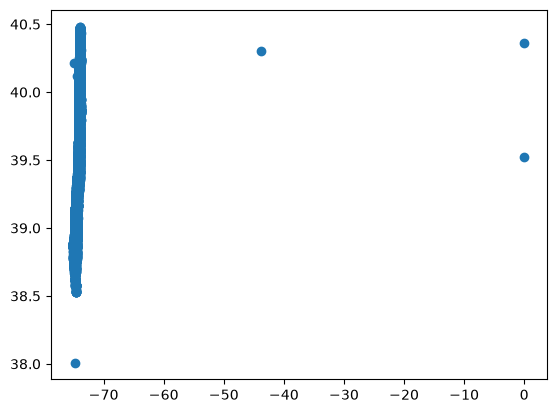

In [90]:
# Before
plt.scatter(dep_full.SLONG,dep_full.SLAT)

In [91]:
## removing outlier data points
dep_full = dep_full.drop(dep_full[(dep_full['SLONG'] < -74.8) & (dep_full['SLAT'] > 40)].index)

dep_full = dep_full.drop(dep_full[(dep_full['SLONG'] < -74.2) & (dep_full['SLAT'] > 40)].index)

dep_full = dep_full.drop(dep_full[(dep_full['SLONG'] > -60)].index)

dep_full = dep_full.drop(dep_full[(dep_full['SLONG'] < -74.7) & (dep_full['SLAT'] < 38.3)].index)

dep_full = dep_full.drop(dep_full[(dep_full['SLONG'] < -74.05) &(dep_full['SLONG'] > -74.1) & (dep_full['SLAT'] < 40.28)& (dep_full['SLAT'] > 40.2)].index)

dep_full = dep_full.drop(dep_full[(dep_full['SLONG'] < -74) &(dep_full['SLONG'] > -74.2) & (dep_full['SLAT'] < 40.6)& (dep_full['SLAT'] > 40.5)].index)

dep_full = dep_full.drop(dep_full[(dep_full['SLONG'] > -73.6)].index)

dep_full = dep_full.drop(dep_full[(dep_full['SLONG'] < -74.5) &(dep_full['SLONG'] > -74.6) & (dep_full['SLAT'] < 40)& (dep_full['SLAT'] > 39.75)].index)

dep_full = dep_full.drop(dep_full[(dep_full['SLONG'] < -74.4) &(dep_full['SLONG'] > -74.6) & (dep_full['SLAT'] < 38.65)& (dep_full['SLAT'] > 38.5)].index)

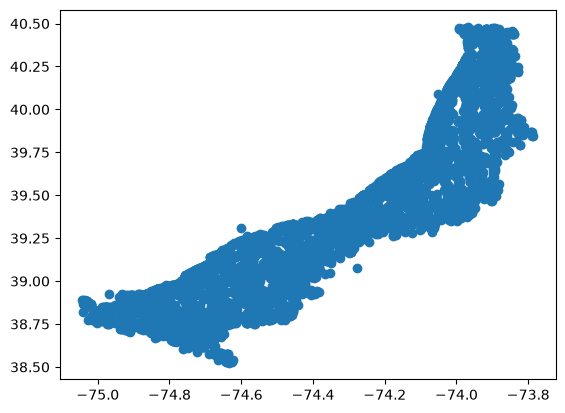

In [92]:
# After! 
plt.scatter(dep_full.SLONG,dep_full.SLAT)

In [93]:
dep_full

,index,year,STRATUM,YRMODA,TIME,MINOUT,STARTDEPTH,ENDDEPTH,MINDEPTH,MAXDEPTH,...,densbot,delta_rho,drho,location,n_s,decade,para_weight,para,para_cpue,para1
ID,,,,,,,,,,,,,,,,,,,,,
19901001,0,1990,20,1990-02-06,855,20.5,16.00,18.000,16.000,18.00,...,1026.188459,0.042819,0.002676,Offshore,South,1990,0.00,0.0,0.00,0.0
19901002,8,1990,19,1990-02-06,1042,19.5,18.00,16.000,15.000,18.00,...,1026.301350,0.065644,0.004103,Midshore,South,1990,0.00,0.0,0.00,0.0
19901003,16,1990,19,1990-02-06,1213,20.0,10.00,9.000,9.000,12.00,...,1025.388754,0.047006,0.002938,Midshore,South,1990,0.00,0.0,0.00,0.0
19901004,31,1990,23,1990-02-07,905,20.0,20.00,24.000,20.000,26.00,...,1027.043907,-0.700424,-0.043777,Offshore,South,1990,0.00,0.0,0.00,0.0
19901005,42,1990,22,1990-02-07,1040,20.7,20.00,18.000,18.000,21.00,...,1024.256347,-0.292292,-0.018268,Midshore,South,1990,0.00,0.0,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20195144,117242,2019,17,2019-11-10,1516,20.0,26.84,25.010,24.705,26.84,...,1024.028532,0.131164,0.007287,Offshore,North,2010,1.49,1.0,0.05,1.0
20195145,117258,2019,17,2019-11-10,1627,20.0,22.57,23.180,NaN,NaN,...,1024.095353,0.155367,0.008632,Offshore,North,2010,0.00,0.0,0.00,0.0
20195146,117275,2019,17,2019-11-11,657,20.0,21.96,24.400,NaN,NaN,...,1024.437226,0.710364,0.039465,Offshore,North,2010,0.00,0.0,0.00,0.0


In [94]:
# dep_full.to_csv("njdep_sf_gam.csv")

#### Adding along and cross shore distance to the DataFrame

##### calculating the degree dist from the reference point. 

calculate for each point in dataset dist in lat/lon and then convert that to km 

Longitude-- fix conversion to central survey lat or origin point-- use that for the lon conversion
    The issue with this is that you are getting one value for longitude so you wont get the cross shelf changes 

rotate it afterwards to along/cross 

dist east/north to along/cross


In [95]:
dep_full = dep_full.reset_index().set_index("ID")
dep_full

,index,year,STRATUM,YRMODA,TIME,MINOUT,STARTDEPTH,ENDDEPTH,MINDEPTH,MAXDEPTH,...,densbot,delta_rho,drho,location,n_s,decade,para_weight,para,para_cpue,para1
ID,,,,,,,,,,,,,,,,,,,,,
19901001,0,1990,20,1990-02-06,855,20.5,16.00,18.000,16.000,18.00,...,1026.188459,0.042819,0.002676,Offshore,South,1990,0.00,0.0,0.00,0.0
19901002,8,1990,19,1990-02-06,1042,19.5,18.00,16.000,15.000,18.00,...,1026.301350,0.065644,0.004103,Midshore,South,1990,0.00,0.0,0.00,0.0
19901003,16,1990,19,1990-02-06,1213,20.0,10.00,9.000,9.000,12.00,...,1025.388754,0.047006,0.002938,Midshore,South,1990,0.00,0.0,0.00,0.0
19901004,31,1990,23,1990-02-07,905,20.0,20.00,24.000,20.000,26.00,...,1027.043907,-0.700424,-0.043777,Offshore,South,1990,0.00,0.0,0.00,0.0
19901005,42,1990,22,1990-02-07,1040,20.7,20.00,18.000,18.000,21.00,...,1024.256347,-0.292292,-0.018268,Midshore,South,1990,0.00,0.0,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20195144,117242,2019,17,2019-11-10,1516,20.0,26.84,25.010,24.705,26.84,...,1024.028532,0.131164,0.007287,Offshore,North,2010,1.49,1.0,0.05,1.0
20195145,117258,2019,17,2019-11-10,1627,20.0,22.57,23.180,NaN,NaN,...,1024.095353,0.155367,0.008632,Offshore,North,2010,0.00,0.0,0.00,0.0
20195146,117275,2019,17,2019-11-11,657,20.0,21.96,24.400,NaN,NaN,...,1024.437226,0.710364,0.039465,Offshore,North,2010,0.00,0.0,0.00,0.0


In [96]:
### Latitude and Longitudes obtained from Google Earth Pro
longitudes = [-75.099103,-74.964147,-74.864322,-74.789636,-74.703064,-74.696578,-74.572269,-74.413167,-74.362072,-74.197378,-74.099889,-74.032425,-73.966922,-73.984819]
latitudes = [38.812969,38.931803,38.939825,38.994853,39.107247, 39.143886,39.274261,39.359736, 39.405236,39.611958,39.755000,40.102014,40.341317,40.488189]

In [97]:
lat_long = pd.DataFrame({
    'longitude': longitudes,
    'latitude': latitudes
})
lat_long

,longitude,latitude
0,-75.099103,38.812969
1,-74.964147,38.931803
2,-74.864322,38.939825
3,-74.789636,38.994853
4,-74.703064,39.107247
5,-74.696578,39.143886
6,-74.572269,39.274261
7,-74.413167,39.359736
8,-74.362072,39.405236
9,-74.197378,39.611958


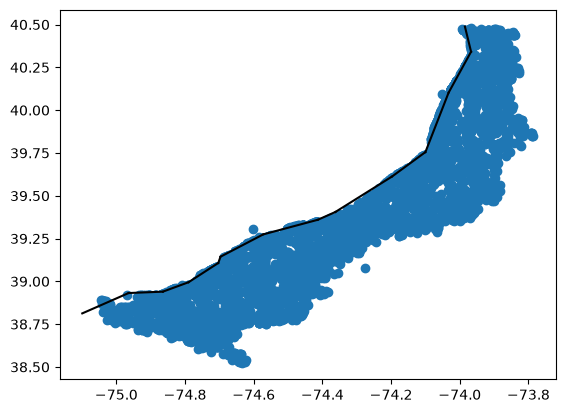

In [98]:
plt.scatter(dep_full.SLONG,dep_full.SLAT)

for i in range(13):
    plt.plot([longitudes[i],longitudes[i+1]],[latitudes[i],latitudes[i+1]],color="k")

In [99]:
ref_lon_km = (-75.099337+ (-75.098822))/2
ref_lat_km = (38.812907 + 38.813308)/2

In [100]:
check_lon_km = -75.04318333333333
check_lat_km = 38.525533333333335

point_lat_km = 38.88966667
point_lon_km = -75.0431833

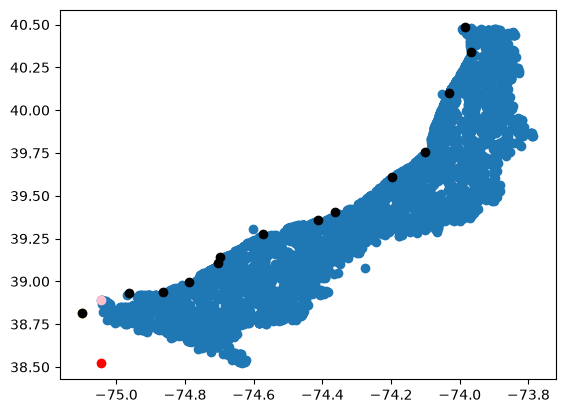

In [101]:
plt.scatter(dep_full.SLONG, dep_full.SLAT)
plt.scatter(check_lon_km, check_lat_km, color='red',label="Min Lat/Lon")
plt.scatter(ref_lon_km,ref_lat_km, color="orange",label='From ArcMap')
plt.scatter(point_lon_km,point_lat_km, color="pink",label='Point Furthest West')
for i in range(14):
    plt.scatter(longitudes[i],latitudes[i],color="k")

In [102]:
##Dividing the Longitude Sections for the diff angles-- this gets the chunks of data in that section 
part1 = dep_full[dep_full.SLAT <= latitudes[1]]
part2 = dep_full[(dep_full.SLAT >= latitudes[1]) & (dep_full.SLAT <= latitudes[2])]
part3 = dep_full[(dep_full.SLAT >= latitudes[2] )& (dep_full.SLAT <= latitudes[3])]
part4 = dep_full[(dep_full.SLAT >= latitudes[3]) & (dep_full.SLAT <= latitudes[4])]
part5 = dep_full[(dep_full.SLAT >= latitudes[4]) & (dep_full.SLAT <= latitudes[5])]
part6 = dep_full[(dep_full.SLAT >= latitudes[5]) & (dep_full.SLAT <= latitudes[6])]
part7 = dep_full[(dep_full.SLAT >= latitudes[6]) & (dep_full.SLAT <= latitudes[7])]
part8 = dep_full[(dep_full.SLAT >= latitudes[7]) & (dep_full.SLAT <= latitudes[8])]
part9 = dep_full[(dep_full.SLAT >= latitudes[8]) & (dep_full.SLAT <= latitudes[9])]
part10 = dep_full[(dep_full.SLAT >= latitudes[9]) & (dep_full.SLAT <= latitudes[10])]
part11 = dep_full[(dep_full.SLAT >= latitudes[10]) & (dep_full.SLAT <= latitudes[11])]
part12 = dep_full[(dep_full.SLAT >= latitudes[11]) & (dep_full.SLAT <= latitudes[12])]
part13 = dep_full[(dep_full.SLAT >= latitudes[12]) & (dep_full.SLAT <= latitudes[13])]

In [103]:
##This separates the lat/lon of each chunck 
part1_lat = part1.SLAT - latitudes[0]
part1_lon = part1.SLONG - longitudes[0]

part2_lat = (part2.SLAT - latitudes[1])
part2_lon = part2.SLONG - longitudes[1]

part3_lat = part3.SLAT - latitudes[2]
part3_lon = part3.SLONG - longitudes[2]

part4_lat = part4.SLAT - latitudes[3]
part4_lon = part4.SLONG - longitudes[3]

part5_lat = part5.SLAT - latitudes[4]
part5_lon = part5.SLONG - longitudes[4]

part6_lat = part6.SLAT - latitudes[5]
part6_lon = part6.SLONG - longitudes[5]

part7_lat = part7.SLAT - latitudes[6]
part7_lon = part7.SLONG - longitudes[6]

part8_lat = part8.SLAT - latitudes[7]
part8_lon = part8.SLONG - longitudes[7]

part9_lat = part9.SLAT - latitudes[8]
part9_lon = part9.SLONG - longitudes[8]

part10_lat = part10.SLAT - latitudes[9]
part10_lon = part10.SLONG - longitudes[9]

part11_lat = part11.SLAT - latitudes[10]
part11_lon = part11.SLONG - longitudes[10]

part12_lat = part12.SLAT - latitudes[11]
part12_lon = part12.SLONG - longitudes[11]

part13_lat = part13.SLAT - latitudes[12]
part13_lon = part13.SLONG - longitudes[12]

In [104]:
seg1_lat = latitudes[1]-latitudes[0]
seg1_lon = longitudes[1]-longitudes[0]

seg2_lat = latitudes[2]-latitudes[1]
seg2_lon = longitudes[2]-longitudes[1]

seg3_lat = latitudes[3]-latitudes[2]
seg3_lon = longitudes[3]-longitudes[2]

seg4_lat = latitudes[4]-latitudes[3]
seg4_lon = longitudes[4]-longitudes[3]

seg5_lat = latitudes[5]-latitudes[4]
seg5_lon = longitudes[5]-longitudes[4]

seg6_lat = latitudes[6]-latitudes[5]
seg6_lon = longitudes[6]-longitudes[5]

seg7_lat = latitudes[7]-latitudes[6]
seg7_lon = longitudes[7]-longitudes[6]

seg8_lat = latitudes[8]-latitudes[7]
seg8_lon = longitudes[8]-longitudes[7]

seg9_lat = latitudes[9]-latitudes[8]
seg9_lon = longitudes[9]-longitudes[8]

seg10_lat = latitudes[10]-latitudes[9]
seg10_lon = longitudes[10]-longitudes[9]

seg11_lat = latitudes[11]-latitudes[10]
seg11_lon = longitudes[11]-longitudes[10]

seg12_lat = latitudes[12]-latitudes[11]
seg12_lon = longitudes[12]-longitudes[11]

seg13_lat = latitudes[13]-latitudes[12]
seg13_lon = longitudes[13]-longitudes[12]

In [105]:
np.cos(39.46527313060218*(np.pi/180))*111.32

np.float64(85.94014958262301)

add along and cross shore after you rotate it brown to red, 

In [106]:
## Converting the Deg dist to km using the lat_dist caluclated as the point to calculate the longitude
part1_lat_km = 111.32 * part1_lat
part1_lon_km = 85.94014958262301 * part1_lon

part2_lat_km = 111.32 * part2_lat
part2_lon_km = 85.94014958262301 * part2_lon

part3_lat_km = 111.32 * part3_lat
part3_lon_km = 85.94014958262301 * part3_lon

part4_lat_km = 111.32 * part4_lat
part4_lon_km = 85.94014958262301 * part4_lon

part5_lat_km = 111.32 * part5_lat
part5_lon_km = 85.94014958262301 * part5_lon

part6_lat_km = 111.32 * part6_lat
part6_lon_km = 85.94014958262301 * part6_lon

part7_lat_km = 111.32 * part7_lat
part7_lon_km = 85.94014958262301 * part7_lon

part8_lat_km = 111.32 * part8_lat
part8_lon_km = 85.94014958262301 * part8_lon

part9_lat_km = 111.32 * part9_lat
part9_lon_km = 85.94014958262301 * part9_lon

part10_lat_km = 111.32 * part10_lat
part10_lon_km = 85.94014958262301 * part10_lon

part11_lat_km = 111.32 * part11_lat
part11_lon_km = 85.94014958262301 * part11_lon

part12_lat_km = 111.32 * part12_lat
part12_lon_km = 85.94014958262301 * part12_lon

part13_lat_km = 111.32 * part13_lat
part13_lon_km = 85.94014958262301 * part13_lon

In [107]:
seg1_lat_km = 111.32 * seg1_lat
seg1_lon_km = 85.94014958262301 * seg1_lon

seg2_lat_km = 111.32 * seg2_lat
seg2_lon_km = 85.94014958262301 * seg2_lon

seg3_lat_km = 111.32 * seg3_lat
seg3_lon_km = 85.94014958262301 * seg3_lon

seg4_lat_km = 111.32 * seg4_lat
seg4_lon_km = 85.94014958262301 * seg4_lon

seg5_lat_km = 111.32 * seg5_lat
seg5_lon_km = 85.94014958262301 * seg5_lon

seg6_lat_km = 111.32 * seg6_lat
seg6_lon_km = 85.94014958262301 * seg6_lon

seg7_lat_km = 111.32 * seg7_lat
seg7_lon_km = 85.94014958262301 * seg7_lon

seg8_lat_km = 111.32 * seg8_lat
seg8_lon_km = 85.94014958262301 * seg8_lon

seg9_lat_km = 111.32 * seg9_lat
seg9_lon_km = 85.94014958262301 * seg9_lon

seg10_lat_km = 111.32 * seg10_lat
seg10_lon_km = 85.94014958262301 * seg10_lon

seg11_lat_km = 111.32 * seg11_lat
seg11_lon_km = 85.94014958262301 * seg11_lon

seg12_lat_km = 111.32 * seg12_lat
seg12_lon_km = 85.94014958262301 * seg12_lon

seg13_lat_km = 111.32 * seg13_lat
seg13_lon_km = 85.94014958262301 * seg13_lon

### Rotating the Piecewise Data

In [108]:
degrees = [41.45,83.18,46.77,31.03,9.15,35.78,54.52,41.75,31.36,27.45,8.42,11.83,-5.21]
radians = np.radians(degrees)
parts_lat = [part1_lat_km,part2_lat_km,part3_lat_km,part4_lat_km,part5_lat_km,part6_lat_km,part7_lat_km,part8_lat_km,part9_lat_km,part10_lat_km,part11_lat_km,part12_lat_km,part13_lat_km]
parts_lon= [part1_lon_km,part2_lon_km,part3_lon_km,part4_lon_km,part5_lon_km,part6_lon_km,part7_lon_km,part8_lon_km,part9_lon_km,part10_lon_km,part11_lon_km,part12_lon_km,part13_lon_km]


seg_lat = [seg1_lat_km,seg2_lat_km,seg3_lat_km,seg4_lat_km,seg5_lat_km,seg6_lat_km,seg7_lat_km,seg8_lat_km,seg9_lat_km,seg10_lat_km,seg11_lat_km,seg12_lat_km,seg13_lat_km]
seg_lon= [seg1_lon_km,seg2_lon_km,seg3_lon_km,seg4_lon_km,seg5_lon_km,seg6_lon_km,seg7_lon_km,seg8_lon_km,seg9_lon_km,seg10_lon_km,seg11_lon_km,seg12_lon_km,seg13_lon_km]

In [109]:
radians

array([ 0.72343897,  1.45176487,  0.81629049,  0.54157567,  0.15969763,
        0.62447881,  0.95155351,  0.72867496,  0.54733525,  0.47909288,
        0.14695672,  0.20647245, -0.09093165])

x = x*np.cos(theta) -y*np.sin(theta)
y = x*np.sin(theta) + y*np.cos(theta)

In [110]:
# part1 rotated 

x1 = (parts_lon[0]*np.cos(radians[0])) -(parts_lat[0]*np.sin(radians[0]))
y1 = (parts_lon[0]*np.sin(radians[0])) +(parts_lat[0]*np.cos(radians[0]))

x2 = (parts_lon[1]*np.cos(radians[1])) -(parts_lat[1]*np.sin(radians[1]))
y2 = (parts_lon[1]*np.sin(radians[1])) +( parts_lat[1]*np.cos(radians[1]))

x3 = (parts_lon[2]*np.cos(radians[2])) -(parts_lat[2]*np.sin(radians[2]))
y3 = (parts_lon[2]*np.sin(radians[2])) +( parts_lat[2]*np.cos(radians[2]))

x4 = (parts_lon[3]*np.cos(radians[3])) -(parts_lat[3]*np.sin(radians[3]))
y4 = (parts_lon[3]*np.sin(radians[3])) +( parts_lat[3]*np.cos(radians[3]))

x5 = (parts_lon[4]*np.cos(radians[4])) -(parts_lat[4]*np.sin(radians[4]))
y5 = (parts_lon[4]*np.sin(radians[4])) +( parts_lat[4]*np.cos(radians[4]))

x6 = (parts_lon[5]*np.cos(radians[5])) -(parts_lat[5]*np.sin(radians[5]))
y6 = (parts_lon[5]*np.sin(radians[5])) +( parts_lat[5]*np.cos(radians[5]))

x7 = (parts_lon[6]*np.cos(radians[6])) -(parts_lat[6]*np.sin(radians[6]))
y7 = (parts_lon[6]*np.sin(radians[6])) +( parts_lat[6]*np.cos(radians[6]))

x8 = (parts_lon[7]*np.cos(radians[7])) -(parts_lat[7]*np.sin(radians[7]))
y8 = (parts_lon[7]*np.sin(radians[7])) +( parts_lat[7]*np.cos(radians[7]))

x9 = (parts_lon[8]*np.cos(radians[8])) -(parts_lat[8]*np.sin(radians[8]))
y9 = (parts_lon[8]*np.sin(radians[8])) +( parts_lat[8]*np.cos(radians[8]))

x10 = (parts_lon[9]*np.cos(radians[9])) -(parts_lat[9]*np.sin(radians[9]))
y10 = (parts_lon[9]*np.sin(radians[9])) +( parts_lat[9]*np.cos(radians[9]))

x11 = (parts_lon[10]*np.cos(radians[10])) -(parts_lat[10]*np.sin(radians[10]))
y11 = (parts_lon[10]*np.sin(radians[10])) +( parts_lat[10]*np.cos(radians[10]))

x12 = (parts_lon[11]*np.cos(radians[11])) -(parts_lat[11]*np.sin(radians[11]))
y12 = (parts_lon[11]*np.sin(radians[11])) +( parts_lat[11]*np.cos(radians[11]))

x13 = (parts_lon[12]*np.cos(radians[12])) -(parts_lat[12]*np.sin(radians[12]))
y13 = (parts_lon[12]*np.sin(radians[12])) +( parts_lat[12]*np.cos(radians[12]))

In [111]:
## These are the point coordinates for each line segment
seg_x1 = (seg_lon[0]*np.cos(radians[0])) -(seg_lat[0]*np.sin(radians[0]))
seg_y1 = (seg_lon[0]*np.sin(radians[0])) +( seg_lat[0]*np.cos(radians[0]))

seg_x2 = (seg_lon[1]*np.cos(radians[1])) -(seg_lat[1]*np.sin(radians[1]))
seg_y2 = (seg_lon[1]*np.sin(radians[1])) +( seg_lat[1]*np.cos(radians[1]))

seg_x3 = (seg_lon[2]*np.cos(radians[2])) -(seg_lat[2]*np.sin(radians[2]))
seg_y3 = (seg_lon[2]*np.sin(radians[2])) +( seg_lat[2]*np.cos(radians[2]))

seg_x4 = (seg_lon[3]*np.cos(radians[3])) -(seg_lat[3]*np.sin(radians[3]))
seg_y4 = (seg_lon[3]*np.sin(radians[3])) +( seg_lat[3]*np.cos(radians[3]))

seg_x5 = (seg_lon[4]*np.cos(radians[4])) -(seg_lat[4]*np.sin(radians[4]))
seg_y5 = (seg_lon[4]*np.sin(radians[4])) +( seg_lat[4]*np.cos(radians[4]))

seg_x6 = (seg_lon[5]*np.cos(radians[5])) -(seg_lat[5]*np.sin(radians[5]))
seg_y6 = (seg_lon[5]*np.sin(radians[5])) +( seg_lat[5]*np.cos(radians[5]))

seg_x7 = (seg_lon[6]*np.cos(radians[6])) -(seg_lat[6]*np.sin(radians[6]))
seg_y7 = (seg_lon[6]*np.sin(radians[6])) +( seg_lat[6]*np.cos(radians[6]))

seg_x8 = (seg_lon[7]*np.cos(radians[7])) -(seg_lat[7]*np.sin(radians[7]))
seg_y8 = (seg_lon[7]*np.sin(radians[7])) +( seg_lat[7]*np.cos(radians[7]))

seg_x9 = (seg_lon[8]*np.cos(radians[8])) -(seg_lat[8]*np.sin(radians[8]))
seg_y9 = (seg_lon[8]*np.sin(radians[8])) +( seg_lat[8]*np.cos(radians[8]))

seg_x10 = (seg_lon[9]*np.cos(radians[9])) -(seg_lat[9]*np.sin(radians[9]))
seg_y10 = (seg_lon[9]*np.sin(radians[9])) +( seg_lat[9]*np.cos(radians[9]))

seg_x11 = (seg_lon[10]*np.cos(radians[10])) -(seg_lat[10]*np.sin(radians[10]))
seg_y11 = (seg_lon[10]*np.sin(radians[10])) +( seg_lat[10]*np.cos(radians[10]))

seg_x12 = (seg_lon[11]*np.cos(radians[11])) -(seg_lat[11]*np.sin(radians[11]))
seg_y12 = (seg_lon[11]*np.sin(radians[11])) +( seg_lat[11]*np.cos(radians[11]))

seg_x13 = (seg_lon[12]*np.cos(radians[12])) -(seg_lat[12]*np.sin(radians[12]))
seg_y13 = (seg_lon[12]*np.sin(radians[12])) +( seg_lat[12]*np.cos(radians[12]))

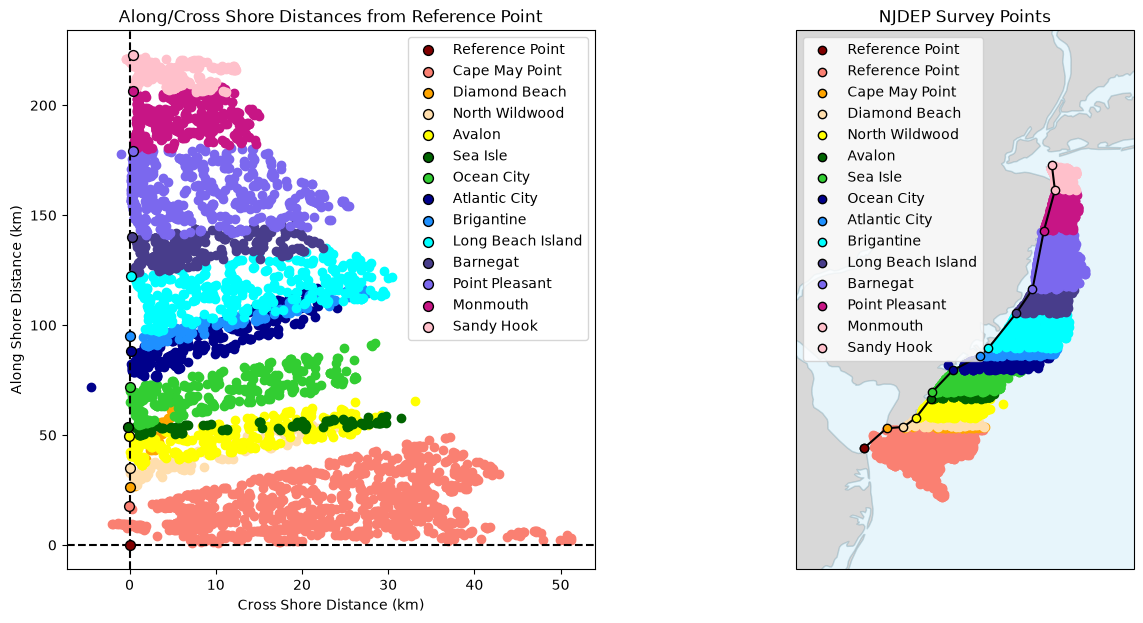

In [112]:
xr = [x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13]
yr = [y1,y2,y3,y4,y5,y6,y7,y8,y9,y10,y11,y12,y13]

seg_xr = [seg_x1,seg_x2,seg_x3,seg_x4,seg_x5,seg_x6,seg_x7,seg_x8,seg_x9,seg_x10,seg_x11,seg_x12,seg_x13]
seg_yr = [seg_y1,seg_y2,seg_y3,seg_y4,seg_y5,seg_y6,seg_y7,seg_y8,seg_y9,seg_y10,seg_y11,seg_y12,seg_y13]

colors = ['salmon','orange','navajowhite','yellow',"darkgreen",'limegreen','darkblue',"dodgerblue",'cyan','darkslateblue',"mediumslateblue",'mediumvioletred',"pink"]

placelabels = ["Reference Point","Cape May Point","Diamond Beach","North Wildwood","Avalon","Sea Isle","Ocean City","Atlantic City","Brigantine","Long Beach Island","Barnegat","Point Pleasant","Monmouth", "Sandy Hook"]

fig = plt.figure(figsize=(15,7))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

# Initialize cumulative offsets
ax0 = fig.add_subplot(gs[0])
cum_xr = 0
cum_yr = 0
cumulative_x_coords = []
cumulative_y_coords = []
xpoint_data = []
ypoint_data = []

ax0.scatter(0,0, color='maroon', s=50, zorder=10000,label="Reference Point",edgecolor="k")
# Loop through all points
something_x = []
something_y = []

for i in range(len(xr)):
    x_points = xr[i] +cum_xr
    y_points = yr[i] +cum_yr
    
    ax0.scatter(x_points, y_points,color=colors[i])

    xpoint_data.append(x_points)
    ypoint_data.append(y_points)
    
    # Add the current segment offset to the cumulative total
    if i < len(seg_xr):  # Avoid index error
        cum_xr += seg_xr[i]
        cum_yr += seg_yr[i]

    cumulative_x_coords.append(cum_xr)
    cumulative_y_coords.append(cum_yr)
    
    ax0.scatter(cum_xr,cum_yr,zorder=1000,color=colors[i], edgecolor="k",s=50,label=placelabels[i+1])

ax0.axhline(0, ls='--',color='k')
ax0.axvline(0, ls='--',color='k')
    

ax0.set_xlabel("Cross Shore Distance (km)")
ax0.set_ylabel("Along Shore Distance (km)")
ax0.set_title("Along/Cross Shore Distances from Reference Point")
ax0.legend()


ax1 = fig.add_subplot(gs[1],projection=ccrs.PlateCarree())
ax1.set_extent([-75.5, -73.5, 38.3, 41.5])
ax1.add_feature(cfeature.LAND, color="grey", alpha=0.3)
ax1.add_feature(cfeature.OCEAN, color="skyblue", alpha=0.2)


parts = [part1,part2,part3,part4,part5,part6,part7,part8,part9,part10,part11,part12,part13]
for i in range(len(parts)):
    ax1.scatter(parts[i].SLONG, parts[i].SLAT, color=colors[i])


ax1.scatter(longitudes[0],latitudes[0], color='maroon', zorder=10000,label="Reference Point",edgecolor="k")
for i in range(len(longitudes)-1):
    ax1.scatter(longitudes[i],latitudes[i],color=colors[i],zorder=1000,edgecolor='k',label=placelabels[i])
    ax1.plot([longitudes[i],longitudes[i+1]],[latitudes[i],latitudes[i+1]],color="k")

ax1.scatter(longitudes[-1], latitudes[-1],c=colors[-1],label=placelabels[-1],zorder=1000,edgecolor='k') 
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.set_title("NJDEP Survey Points")
ax1.legend()

# plt.savefig("along_cross_surveypoints.jpeg",dpi=300,bbox_inches='tight');


In [118]:
x_dist_data = pd.DataFrame(pd.DataFrame(xpoint_data).T.bfill(axis=1).iloc[:,0]).rename(columns = {0 :"x_dist"}).sort_index(ascending=True)
y_dist_data = pd.DataFrame(pd.DataFrame(ypoint_data).T.bfill(axis=1).iloc[:,0]).rename(columns = {0 :"y_dist"}).sort_index(ascending=True)
combo1 = pd.merge(x_dist_data,y_dist_data,on="ID", how='left').sort_index()
combo2 = pd.merge(dep_full,combo1,on="ID",how='left').sort_index()
combo2 = combo2.drop(columns={'index'})

In [119]:
combo2

,year,STRATUM,YRMODA,TIME,MINOUT,STARTDEPTH,ENDDEPTH,MINDEPTH,MAXDEPTH,SLAT,...,drho,location,n_s,decade,para_weight,para,para_cpue,para1,x_dist,y_dist
ID,,,,,,,,,,,,,,,,,,,,,
19901001,1990,20,1990-02-06,855,20.5,16.00,18.000,16.000,18.00,39.351500,...,0.002676,Offshore,South,1990,0.00,0.0,0.00,0.0,11.203525,102.299765
19901002,1990,19,1990-02-06,1042,19.5,18.00,16.000,15.000,18.00,39.314667,...,0.004103,Midshore,South,1990,0.00,0.0,0.00,0.0,10.876190,94.776159
19901003,1990,19,1990-02-06,1213,20.0,10.00,9.000,9.000,12.00,39.387667,...,0.002938,Midshore,South,1990,0.00,0.0,0.00,0.0,4.678182,96.605073
19901004,1990,23,1990-02-07,905,20.0,20.00,24.000,20.000,26.00,39.158000,...,-0.043777,Offshore,South,1990,0.00,0.0,0.00,0.0,18.809184,69.377030
19901005,1990,22,1990-02-07,1040,20.7,20.00,18.000,18.000,21.00,39.065667,...,-0.018268,Midshore,South,1990,0.00,0.0,0.00,0.0,17.353040,54.727214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20195144,2019,17,2019-11-10,1516,20.0,26.84,25.010,24.705,26.84,39.792000,...,0.007287,Offshore,North,2010,1.49,1.0,0.05,1.0,17.022285,146.788868
20195145,2019,17,2019-11-10,1627,20.0,22.57,23.180,NaN,NaN,39.867733,...,0.008632,Offshore,North,2010,0.00,0.0,0.00,0.0,15.524259,155.089621
20195146,2019,17,2019-11-11,657,20.0,21.96,24.400,NaN,NaN,39.996833,...,0.039465,Offshore,North,2010,0.00,0.0,0.00,0.0,14.187835,169.419804


In [120]:
combo2.to_csv("njdep_sf_gam.csv") ## Full DFrame with hte SF data and the along and cross shore distance 

Original CRS: COMPD_CS["NAD83 / New Jersey (ftUS) + NAVD88 depth (ftUS)",PROJCS["NAD83 / New Jersey (ftUS)",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38.8333333333333],PARAMETER["central_meridian",-74.5],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",492125],PARAMETER["false_northing",0],UNIT["US survey foot",0.304800609601219,AUTHORITY["EPSG","9003"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3424"]],VERT_CS["NAVD88 depth (ftUS)",VERT_DATUM["North American Vertical Datum 1988",2005,AUTHORITY["EPSG","5103"]],UNIT["US survey foot",0.304800609601219,AUTHORITY["EPSG","9003"]],AXIS["Depth",DOWN],AUTHORITY["EPSG","6358"]]]
Updated CRS: EPSG:4326


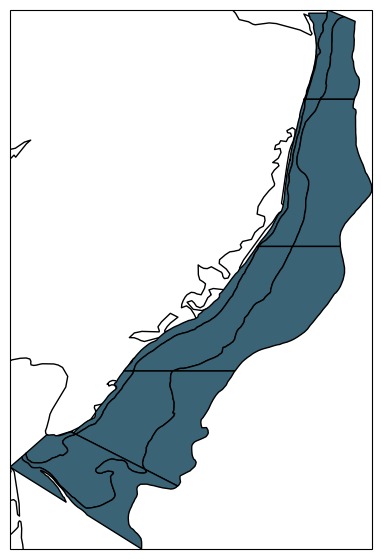

In [59]:
### Fixing the shapefile to be in the right projection
fname = 'Ocean_Trawl_Strata_20210128.shp'
nj = gpd.read_file(fname)

# Check the current CRS
print("Original CRS:", nj.crs)

# If it's not in EPSG:4326, convert it
if nj.crs is None:
    print("Warning: No CRS found! Assigning EPSG:4326 as a guess.")
    nj = nj.set_crs("EPSG:4326")  # Assign if missing

elif nj.crs.to_string() != "EPSG:4326":
    nj = nj.to_crs("EPSG:4326")  # Convert projection

print("Updated CRS:", nj.crs)

# Create plot
fig, ax = plt.subplots(figsize=(20, 7), subplot_kw={'projection': ccrs.PlateCarree()})

# Add geometries
ax.add_geometries(nj.geometry, crs=ccrs.PlateCarree(), facecolor='#3A6476', edgecolor='black', zorder=1000)

# Add coastlines for reference
ax.coastlines()

# Set extent to zoom in on the data
ax.set_extent([nj.total_bounds[0], nj.total_bounds[2], 
               nj.total_bounds[1], nj.total_bounds[3]], crs=ccrs.PlateCarree())

# Show plot
plt.show()

In [54]:
part2_removed = combo2[~((combo2.SLAT >= latitudes[1]) & (combo2.SLAT <= latitudes[2]))] ## Need to do this because it messes up the plot

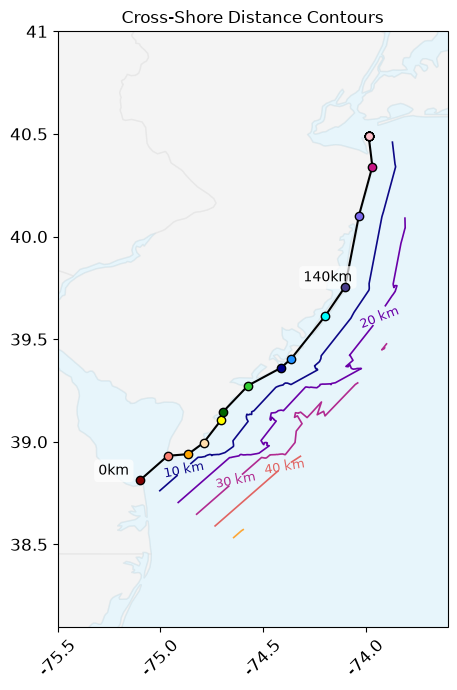

In [55]:
lon = part2_removed['SLONG'].to_numpy() 
lat = part2_removed['SLAT'].to_numpy() 
z = part2_removed['x_dist'].to_numpy() 

xi = np.linspace(lon.min(), lon.max(), 400)
yi = np.linspace(lat.min(), lat.max(), 400)
Xi, Yi = np.meshgrid(xi, yi)

# 2. Interpolate z onto this grid
Zi = griddata((lon, lat), z, (Xi, Yi), method='cubic')



colors = ['maroon','salmon','orange','navajowhite','yellow',"darkgreen",'limegreen','darkblue',"dodgerblue",'cyan','darkslateblue',"mediumslateblue",'mediumvioletred','pink'] 
placelabels = ["Reference Point","Cape May Point","Diamond Beach","North Wildwood","Avalon","Sea Isle","Ocean City","Atlantic City","Brigantine","Long Beach Island","Barnegat","Point Pleasant","Monmouth", "Sandy Hook"] 
y_coords = ["0km","18km","26km","35km","50km","54km","72km","88km","95km","122km","140km","179km","206km","223km"] 

annotate_indices = [0,10,15,20,25] 

tri = mtri.Triangulation(lon, lat) 

proj = ccrs.PlateCarree() 
fig = plt.figure(figsize=(20,7)) 
ax = plt.axes(projection=proj) 

ax.add_feature(cfeature.STATES, color="gainsboro", alpha=0.3) 
ax.add_feature(cfeature.OCEAN, color="skyblue", alpha=0.2) 
ax.set_extent([-75.5, -73.6, 38.3, 41]) 
ax.set_xticks([-75.5, -75.0, -74.5, -74.0]) 
ax.set_yticks([38.5, 39.0, 39.5,40.0, 40.5,41]) 
ax.set_xticklabels([-75.5, -75.0, -74.5, -74.0],fontsize=12,rotation=45) 
ax.set_yticklabels([38.5, 39.0, 39.5,40.0, 40.5,41],fontsize=12) 

for i in range(len(longitudes) - 1): 
    ax.scatter(longitudes[i],latitudes[i],color=colors[i],zorder=1000,edgecolor='k',label=placelabels[i]) 
    ax.plot([longitudes[i],longitudes[i+1]],[latitudes[i],latitudes[i+1]],color="k") 
    ax.scatter(longitudes[-1], latitudes[-1],label=placelabels[-1],color='pink',zorder=1000,edgecolor='k') 
    
for i in annotate_indices: 
    if i < len(longitudes): 
        # Ensure index is within the bounds 
        ax.annotate(y_coords[i], 
                    # Text (or use placelabels[i] if preferred) 
                    (longitudes[i], latitudes[i]), 
                    # Coordinates 
                    textcoords="offset points", 
                    # Specifies that the text will be placed relative to the point 
                    xytext=(-30, 4), 
                    # Offset to prevent overlap (you can increase this value if needed) 
                    fontsize=10, 
                    # arrowprops=arrowprops, 
                    color="black", 
                    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", boxstyle="round,pad=0.3"))
        
# Isolines every 10 km 
levels = np.arange(10, 61, 10) 
cs = ax.tricontour(tri, z, levels=levels, cmap='plasma', linewidths=1.2, transform=proj) 
ax.clabel(cs, fmt='%d km', inline=True, fontsize=9) 
ax.set_title('Cross-Shore Distance Contours') 
        
plt.tight_layout() 

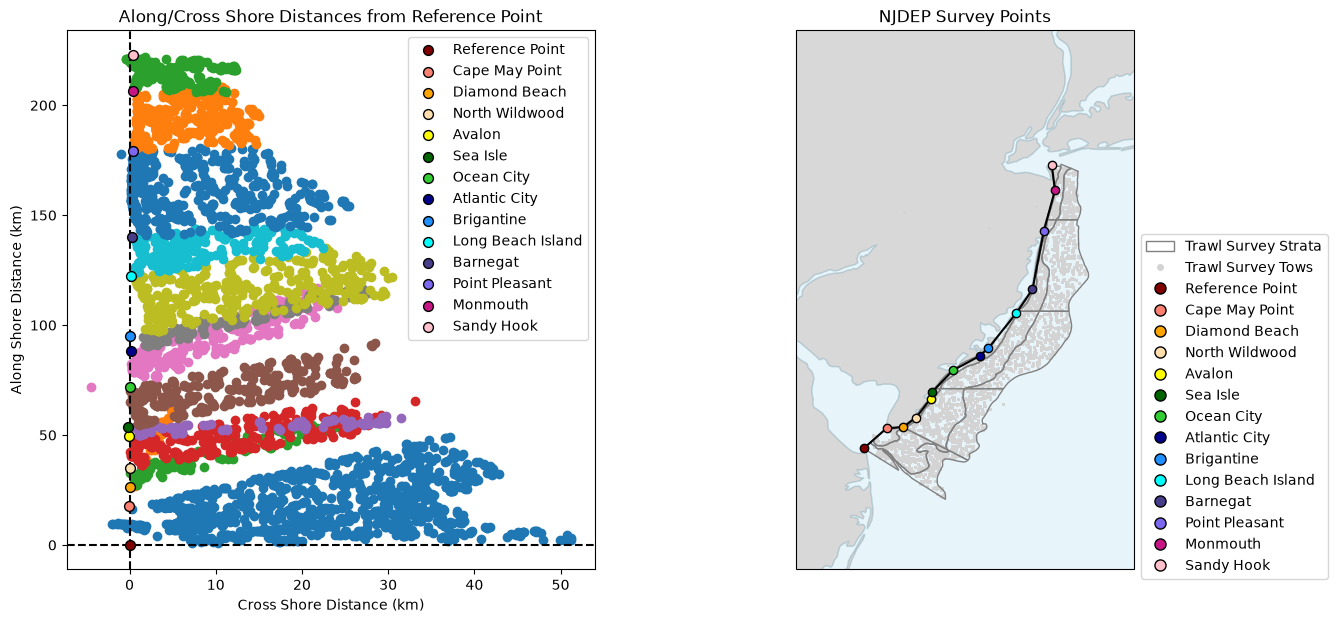

In [56]:
xr = [x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13]
yr = [y1,y2,y3,y4,y5,y6,y7,y8,y9,y10,y11,y12,y13]

seg_xr = [seg_x1,seg_x2,seg_x3,seg_x4,seg_x5,seg_x6,seg_x7,seg_x8,seg_x9,seg_x10,seg_x11,seg_x12,seg_x13]
seg_yr = [seg_y1,seg_y2,seg_y3,seg_y4,seg_y5,seg_y6,seg_y7,seg_y8,seg_y9,seg_y10,seg_y11,seg_y12,seg_y13]

colors = ['maroon','salmon','orange','navajowhite','yellow',"darkgreen",'limegreen','darkblue',"dodgerblue",'cyan','darkslateblue',"mediumslateblue",'mediumvioletred','pink']

placelabels = ["Reference Point","Cape May Point","Diamond Beach","North Wildwood","Avalon","Sea Isle","Ocean City","Atlantic City","Brigantine","Long Beach Island","Barnegat","Point Pleasant","Monmouth", "Sandy Hook"]

fig = plt.figure(figsize=(15,7))
# gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

# Initialize cumulative offsets
ax0 = fig.add_subplot(gs[0])
cum_xr = 0
cum_yr = 0
cumulative_x_coords = []
cumulative_y_coords = []
xpoint_data = []
ypoint_data = []

ax0.scatter(0,0, color='maroon', s=50, zorder=10000,label="Reference Point",edgecolor="k")

# Loop through all points
something_x = []
something_y = []

for i in range(len(xr)):
    x_points = xr[i] +cum_xr
    y_points = yr[i] +cum_yr
    
    ax0.scatter(x_points, y_points)

    xpoint_data.append(x_points)
    ypoint_data.append(y_points)
    
    # Add the current segment offset to the cumulative total
    if i < len(seg_xr):  # Avoid index error
        cum_xr += seg_xr[i]
        cum_yr += seg_yr[i]

    cumulative_x_coords.append(cum_xr)
    cumulative_y_coords.append(cum_yr)
    
    ax0.scatter(cum_xr,cum_yr,zorder=1000,color=colors[i+1], edgecolor="k",s=50,label=placelabels[i+1])

ax0.axhline(0, ls='--',color='k')
ax0.axvline(0, ls='--',color='k')
    

ax0.set_xlabel("Cross Shore Distance (km)")
ax0.set_ylabel("Along Shore Distance (km)")
ax0.set_title("Along/Cross Shore Distances from Reference Point")
ax0.legend()


ax1 = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())
ax1.set_extent([-75.5, -73.5, 38.3, 41.5])
ax1.add_feature(cfeature.LAND, color="grey", alpha=0.3)
ax1.add_feature(cfeature.OCEAN, color="skyblue", alpha=0.2)
ax1.scatter(df.SLONG, df.SLAT,s=5,color='lightgray',marker=".",label="Trawl Survey Tows")


for i in range(len(longitudes) - 1):
    ax1.scatter(longitudes[i],latitudes[i],color=colors[i],zorder=1000,edgecolor='k',label=placelabels[i])
    ax1.plot([longitudes[i],longitudes[i+1]],[latitudes[i],latitudes[i+1]],color="k")

# ax1.scatter(longitudes[0], latitudes[0], color="k",s=50, label="Reference Point",edgecolor='k',zorder=10000)
ax1.scatter(longitudes[-1], latitudes[-1],c=colors[-1],label=placelabels[-1],zorder=1000,edgecolor='k')
ax1.add_geometries(nj.geometry, crs=ccrs.PlateCarree(),edgecolor='grey',facecolor="none",label="Trawl Survey Strata")

ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.set_title("NJDEP Survey Points")
strata_patch = mpatches.Patch(edgecolor='grey', facecolor="none", label="Trawl Survey Strata")
tows_marker = mlines.Line2D([], [], color='lightgray', marker='.', linestyle='None', markersize=8, label="Trawl Survey Tows")

# Define legend handles for placelabels
place_patches = [mlines.Line2D([], [], color=colors[i], marker='o', linestyle='None', 
                               markersize=8, markeredgecolor='k', label=placelabels[i]) 
                 for i in range(len(placelabels))]

# Combine all legend items
legend_handles = [strata_patch, tows_marker] + place_patches

# Add the legend
ax1.legend(handles=legend_handles,bbox_to_anchor=(1, 0.635), fontsize=10, frameon=True)

# plt.savefig("Figures/NewGAMFigs/along_cross.png",dpi=300);

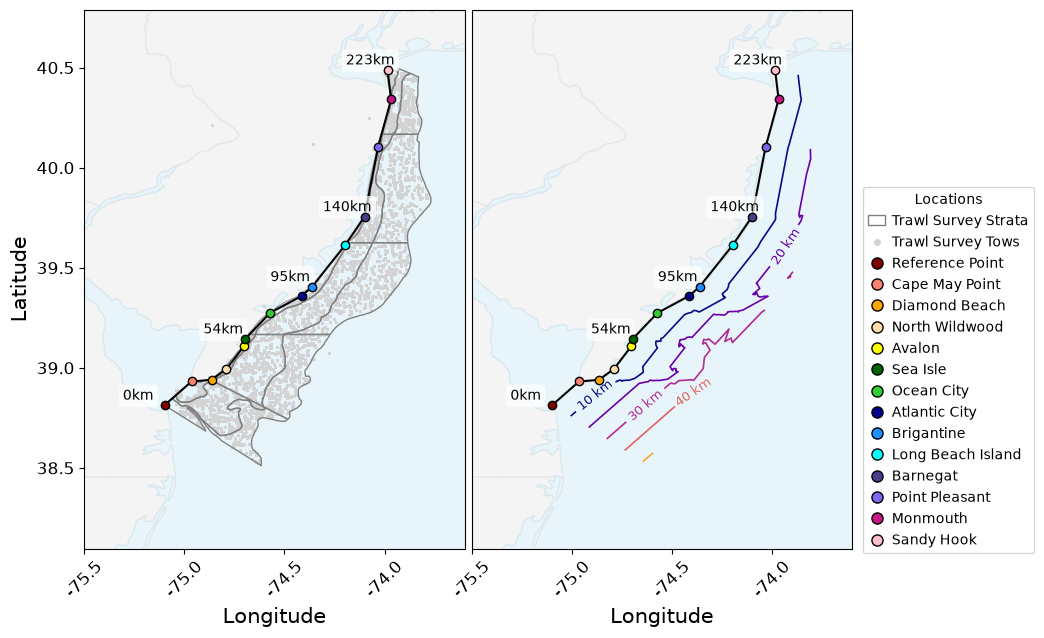

In [ ]:
colors = ['maroon','salmon','orange','navajowhite','yellow',"darkgreen",'limegreen','darkblue',"dodgerblue",'cyan','darkslateblue',"mediumslateblue",'mediumvioletred','pink']
placelabels = ["Reference Point","Cape May Point","Diamond Beach","North Wildwood","Avalon","Sea Isle","Ocean City","Atlantic City","Brigantine","Long Beach Island","Barnegat","Point Pleasant","Monmouth", "Sandy Hook"]

y_coords = ["0km","18km","26km","35km","50km","54km","72km","88km","95km","122km","140km","179km","206km","223km"]

annotate_indices = [0,5,8,10,13]

fig,ax = plt.subplots(1,2,figsize=(10,7), sharey=True, subplot_kw={'projection': ccrs.PlateCarree()},gridspec_kw={'wspace': 0})

ax[0].set_extent([-75.5, -73.6, 38.3, 41])


#### Plot 1 ####
ax[0].add_geometries(nj.geometry, crs=ccrs.PlateCarree(),edgecolor='grey',facecolor="none",label="Trawl Survey Strata")

ax[0].add_feature(cfeature.STATES, color="gainsboro", alpha=0.3)
ax[0].add_feature(cfeature.OCEAN, color="skyblue", alpha=0.2)

ax[0].scatter(df.SLONG, df.SLAT,s=5,color='lightgray',marker=".",label="Trawl Survey Tows")


for i in range(len(longitudes) - 1):
    ax[0].scatter(longitudes[i],latitudes[i],color=colors[i],zorder=1000,edgecolor='k',label=placelabels[i])
    ax[0].plot([longitudes[i],longitudes[i+1]],[latitudes[i],latitudes[i+1]],color="k")

ax[0].scatter(longitudes[-1], latitudes[-1],label=placelabels[-1],color='pink',zorder=1000,edgecolor='k')


for i in annotate_indices:
    if i < len(longitudes):  # Ensure index is within the bounds
        ax[0].annotate(
            y_coords[i],  # Text (or use placelabels[i] if preferred)
            (longitudes[i], latitudes[i]),  # Coordinates
            textcoords="offset points",  # Specifies that the text will be placed relative to the point
            xytext=(-30, 4),  # Offset to prevent overlap (you can increase this value if needed)
            fontsize=10,
            # arrowprops=arrowprops,
            color="black",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", boxstyle="round,pad=0.3")  # Make text box readable
        )
    else:
        print(f"Index {i} is out of range for longitudes and latitudes")
        
ax[0].set_xticks([-75.5, -75.0, -74.5, -74.0])  
ax[0].set_yticks([38.5, 39.0, 39.5,40.0, 40.5,41])
ax[0].set_xticklabels([-75.5, -75.0, -74.5, -74.0],fontsize=12,rotation=45)
ax[0].set_yticklabels([38.5, 39.0, 39.5,40.0, 40.5,41],fontsize=12)

ax[0].set_xlabel("Longitude",fontsize=15)
ax[0].set_ylabel("Latitude",fontsize=15)

### Cross Shore Distance Plot ###
lon = part2_removed['SLONG'].to_numpy()
lat = part2_removed['SLAT'].to_numpy()
z   = part2_removed['x_dist'].to_numpy()
tri = mtri.Triangulation(lon, lat)

ax[1].add_feature(cfeature.STATES, color="gainsboro", alpha=0.3)
ax[1].add_feature(cfeature.OCEAN, color="skyblue", alpha=0.2)

ax[1].set_extent([-75.5, -73.6, 38.3, 41])


ax[1].set_xticks([-75.5, -75.0, -74.5, -74.0])  
# ax[1].set_yticks([38.5, 39.0, 39.5,40.0, 40.5,41])
ax[1].set_xticklabels([-75.5, -75.0, -74.5, -74.0],fontsize=12,rotation=45)
# ax[1].set_yticklabels([38.5, 39.0, 39.5,40.0, 40.5,41],fontsize=12)

ax[1].set_xlabel("Longitude",fontsize=15)
# ax[1].set_ylabel("Latitude",fontsize=15)

for i in range(len(longitudes) - 1):
    ax[1].scatter(longitudes[i],latitudes[i],color=colors[i],zorder=1000,edgecolor='k',label=placelabels[i])
    ax[1].plot([longitudes[i],longitudes[i+1]],[latitudes[i],latitudes[i+1]],color="k")

ax[1].scatter(longitudes[-1], latitudes[-1],label=placelabels[-1],color='pink',zorder=1000,edgecolor='k')

for i in annotate_indices:
    if i < len(longitudes):  # Ensure index is within the bounds
        ax[1].annotate(
            y_coords[i],  # Text (or use placelabels[i] if preferred)
            (longitudes[i], latitudes[i]),  # Coordinates
            textcoords="offset points",  # Specifies that the text will be placed relative to the point
            xytext=(-30, 4),  # Offset to prevent overlap (you can increase this value if needed)
            fontsize=10,
            # arrowprops=arrowprops,
            color="black",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", boxstyle="round,pad=0.3")  # Make text box readable
        )
    else:
        print(f"Index {i} is out of range for longitudes and latitudes")
        
# ax[1].add_geometries(nj.geometry, crs=ccrs.PlateCarree(),edgecolor='grey',facecolor="none",label="Trawl Survey Strata")

# Isolines every 10 km
levels = np.arange(10, 61, 10)
cs = ax[1].tricontour(tri, z, levels=levels, cmap='plasma', linewidths=1.2, transform=proj)
ax[1].clabel(cs, fmt='%d km', inline=True, fontsize=9);

# ax[1].set_title('Cross-Shore Distance Contours')

### Legend ### 
# Define legend handles for trawl strata and tows
strata_patch = mpatches.Patch(edgecolor='grey', facecolor="none", label="Trawl Survey Strata")
tows_marker = mlines.Line2D([], [], color='lightgray', marker='.', linestyle='None', markersize=8, label="Trawl Survey Tows")

fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(.9, 0.365),
    frameon=True,
    fontsize=10,
    title="Locations",
    ncol=1,                  # try ncol=2 if you want it shorter/tighter
    handlelength=1.2,
    handletextpad=0.5
);
